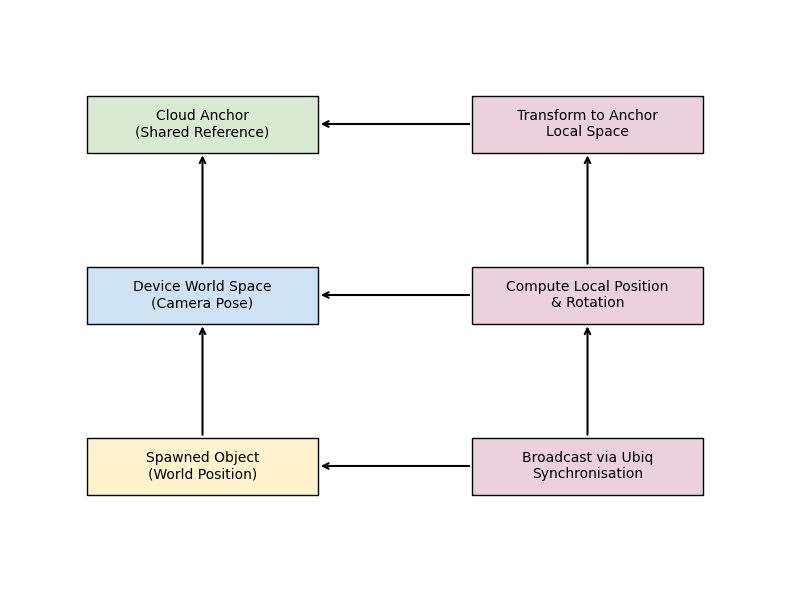

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create figure and axis
fig, ax = plt.subplots(figsize=(8,6))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.axis('off')

# Draw elements
# Cloud Anchor
ax.add_patch(patches.Rectangle((1,7.5), 3, 1, edgecolor='black', facecolor='#d9ead3'))
ax.text(2.5, 8, "Cloud Anchor\n(Shared Reference)", ha='center', va='center', fontsize=10)

# Device
ax.add_patch(patches.Rectangle((1,4.5), 3, 1, edgecolor='black', facecolor='#cfe2f3'))
ax.text(2.5, 5, "Device World Space\n(Camera Pose)", ha='center', va='center', fontsize=10)

# Spawn Point
ax.add_patch(patches.Rectangle((1,1.5), 3, 1, edgecolor='black', facecolor='#fff2cc'))
ax.text(2.5, 2, "Spawned Object\n(World Position)", ha='center', va='center', fontsize=10)

# Process steps
ax.add_patch(patches.Rectangle((6,7.5), 3, 1, edgecolor='black', facecolor='#ead1dc'))
ax.text(7.5, 8, "Transform to Anchor\nLocal Space", ha='center', va='center', fontsize=10)

ax.add_patch(patches.Rectangle((6,4.5), 3, 1, edgecolor='black', facecolor='#ead1dc'))
ax.text(7.5, 5, "Compute Local Position\n& Rotation", ha='center', va='center', fontsize=10)

ax.add_patch(patches.Rectangle((6,1.5), 3, 1, edgecolor='black', facecolor='#ead1dc'))
ax.text(7.5, 2, "Broadcast via Ubiq\nSynchronisation", ha='center', va='center', fontsize=10)

# Arrows
arrowprops = dict(arrowstyle="->", color='black', lw=1.5)
ax.annotate("", xy=(2.5,7.5), xytext=(2.5,5.5), arrowprops=arrowprops)
ax.annotate("", xy=(2.5,4.5), xytext=(2.5,2.5), arrowprops=arrowprops)
ax.annotate("", xy=(4,8), xytext=(6,8), arrowprops=arrowprops)
ax.annotate("", xy=(4,5), xytext=(6,5), arrowprops=arrowprops)
ax.annotate("", xy=(4,2), xytext=(6,2), arrowprops=arrowprops)

# Vertical arrows on right
ax.annotate("", xy=(7.5,7.5), xytext=(7.5,5.5), arrowprops=arrowprops)
ax.annotate("", xy=(7.5,4.5), xytext=(7.5,2.5), arrowprops=arrowprops)

plt.tight_layout()
plt.show()


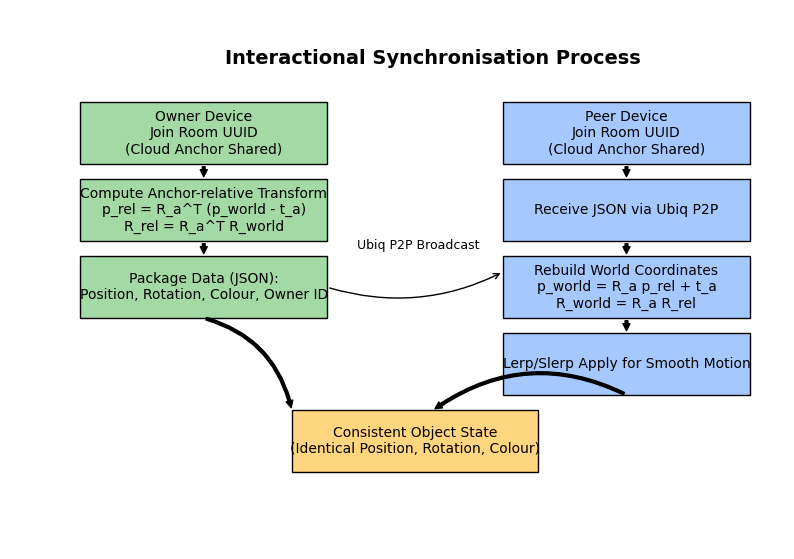

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))
ax.axis('off')

# Colors
owner_color = "#A3D9A5"
peer_color = "#A5C9FF"

# Helper function for box
def draw_box(x, y, text, color, ax, width=3.5, height=0.8):
    rect = Rectangle((x, y), width, height, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=10, wrap=True)

# Helper function for arrow
def draw_arrow(x1, y1, x2, y2, style='simple', connectionstyle="arc3,rad=0.0"):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle=style, mutation_scale=10,
                            connectionstyle=connectionstyle,
                            color="black")
    ax.add_patch(arrow)

# Owner column
draw_box(0, 5, "Owner Device\nJoin Room UUID\n(Cloud Anchor Shared)", owner_color, ax)
draw_box(0, 4, "Compute Anchor-relative Transform\np_rel = R_a^T (p_world - t_a)\nR_rel = R_a^T R_world", owner_color, ax)
draw_box(0, 3, "Package Data (JSON):\nPosition, Rotation, Colour, Owner ID", owner_color, ax)

# Peer column
draw_box(6, 5, "Peer Device\nJoin Room UUID\n(Cloud Anchor Shared)", peer_color, ax)
draw_box(6, 4, "Receive JSON via Ubiq P2P", peer_color, ax)
draw_box(6, 3, "Rebuild World Coordinates\np_world = R_a p_rel + t_a\nR_world = R_a R_rel", peer_color, ax)
draw_box(6, 2, "Lerp/Slerp Apply for Smooth Motion", peer_color, ax)

# Shared final state
draw_box(3, 1, "Consistent Object State\n(Identical Position, Rotation, Colour)", "#FFD580", ax)

# Arrows inside Owner
draw_arrow(1.75, 5, 1.75, 4.8)
draw_arrow(1.75, 4, 1.75, 3.8)

# Arrows inside Peer
draw_arrow(7.75, 5, 7.75, 4.8)
draw_arrow(7.75, 4, 7.75, 3.8)
draw_arrow(7.75, 3, 7.75, 2.8)

# Cross-device arrows
draw_arrow(3.5, 3.4, 6, 3.6, style='->', connectionstyle="arc3,rad=0.2")
ax.text(4.8, 3.9, "Ubiq P2P Broadcast", fontsize=9, ha='center')

# Arrows to final state
draw_arrow(1.75, 3, 3, 1.8, connectionstyle="arc3,rad=-0.3")
draw_arrow(7.75, 2, 5, 1.8, connectionstyle="arc3,rad=0.3")

# Title
ax.text(5, 6.3, "Interactional Synchronisation Process", fontsize=14, ha='center', fontweight='bold')

plt.xlim(-1, 10)
plt.ylim(0, 7)
plt.show()


C:\Users\PeggyTsai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24231 (\N{CJK UNIFIED IDEOGRAPH-5EA7}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PeggyTsai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PeggyTsai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PeggyTsai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PeggyTsai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from current font.
  fig.canvas

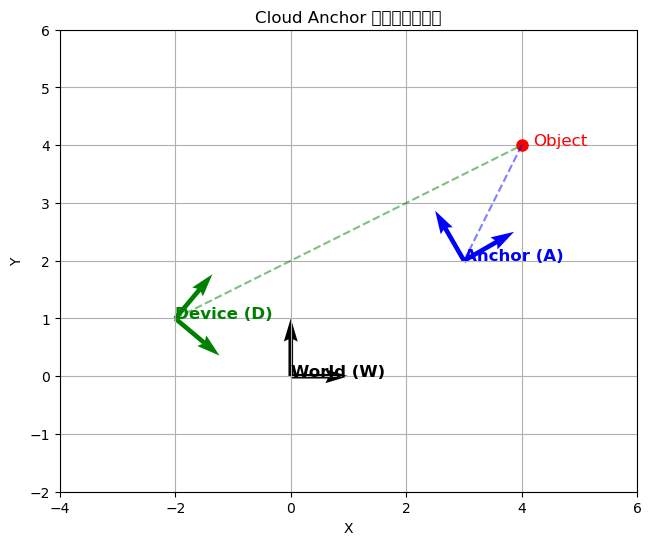

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 建立畫布
fig, ax = plt.subplots(figsize=(8, 6))

# 定義座標系的繪製函數
def draw_frame(origin, R, label, color):
    ax.quiver(origin[0], origin[1], R[0, 0], R[1, 0], angles='xy', scale_units='xy', scale=1, color=color, width=0.008)
    ax.quiver(origin[0], origin[1], R[0, 1], R[1, 1], angles='xy', scale_units='xy', scale=1, color=color, width=0.008)
    ax.text(origin[0], origin[1], f"{label}", fontsize=12, color=color, fontweight='bold')

# 世界座標 (W)
origin_W = np.array([0, 0])
R_W = np.eye(2)

# 錨點座標系 (A)
origin_A = np.array([3, 2])
theta_A = np.deg2rad(30)
R_A = np.array([[np.cos(theta_A), -np.sin(theta_A)],
                [np.sin(theta_A),  np.cos(theta_A)]])

# 裝置座標系 (D)
origin_D = np.array([-2, 1])
theta_D = np.deg2rad(-40)
R_D = np.array([[np.cos(theta_D), -np.sin(theta_D)],
                [np.sin(theta_D),  np.cos(theta_D)]])

# 畫三個座標系
draw_frame(origin_W, R_W, "World (W)", "black")
draw_frame(origin_A, R_A, "Anchor (A)", "blue")
draw_frame(origin_D, R_D, "Device (D)", "green")

# 畫物件位置 (以世界座標表示)
obj_W = np.array([4, 4])
ax.plot(obj_W[0], obj_W[1], 'ro', markersize=8)
ax.text(obj_W[0] + 0.2, obj_W[1], "Object", fontsize=12, color="red")

# 畫連線
ax.plot([origin_D[0], obj_W[0]], [origin_D[1], obj_W[1]], 'g--', alpha=0.5)
ax.plot([origin_A[0], obj_W[0]], [origin_A[1], obj_W[1]], 'b--', alpha=0.5)

# 圖片設置
ax.set_xlim(-4, 6)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Cloud Anchor 座標轉換示意圖")

plt.grid(True)
plt.show()


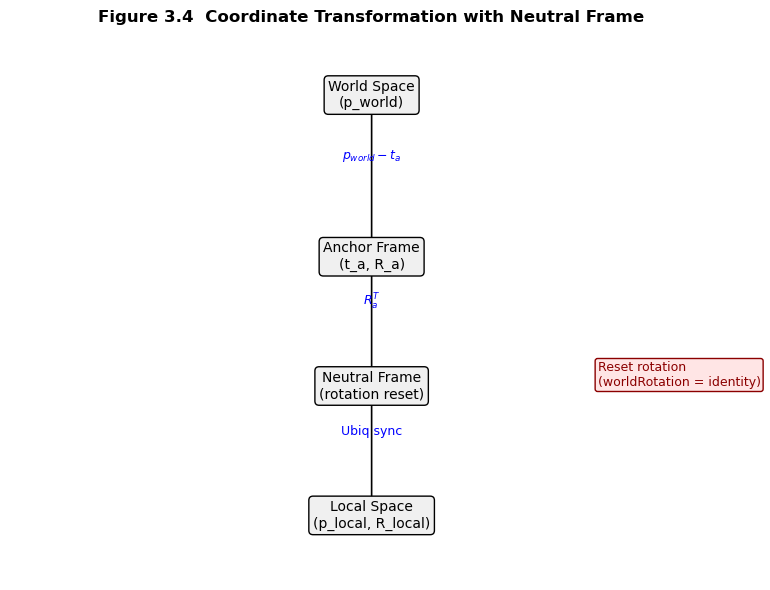

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# 建立畫布
fig, ax = plt.subplots(figsize=(8, 6))

# 節點座標
nodes = {
    "World Space\n(p_world)": (0, 2.5),
    "Anchor Frame\n(t_a, R_a)": (0, 0),
    "Neutral Frame\n(rotation reset)": (0, -2),
    "Local Space\n(p_local, R_local)": (0, -4)
}

# 繪製節點
for name, (x, y) in nodes.items():
    ax.text(x, y, name, ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="black", lw=1),
            fontsize=10)

# 繪製箭頭
def draw_arrow(start, end, text=None):
    arrow = FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=15, lw=1.2)
    ax.add_patch(arrow)
    if text:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
        ax.text(mx, my + 0.3, text, ha='center', va='center', fontsize=9, color='blue')

draw_arrow(nodes["World Space\n(p_world)"], nodes["Anchor Frame\n(t_a, R_a)"], r"$p_{world} - t_a$")
draw_arrow(nodes["Anchor Frame\n(t_a, R_a)"], nodes["Neutral Frame\n(rotation reset)"], r"$R_a^T$")
draw_arrow(nodes["Neutral Frame\n(rotation reset)"], nodes["Local Space\n(p_local, R_local)"], "Ubiq sync")

# 標註 Neutral Frame 關鍵
ax.text(2.5, -2, "Reset rotation\n(worldRotation = identity)", fontsize=9, color='darkred',
        bbox=dict(boxstyle="round,pad=0.2", fc="#ffe5e5", ec="darkred"))

# 圖片美化
ax.set_xlim(-4, 4)
ax.set_ylim(-5, 3.5)
ax.axis('off')

plt.title("Figure 3.4  Coordinate Transformation with Neutral Frame", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()
